<a href="https://colab.research.google.com/github/apesnajnin1/Python_Data-Analytics_PGD/blob/main/Final_Project_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# 1. Load your data
from google.colab import files
uploaded = files.upload()
import pandas as pd
df = pd.read_csv('data_Maldives_f.csv')
print(df)

Saving data_Maldives_f.csv to data_Maldives_f.csv
    Unnamed: 0.1  Unnamed: 0 Region Name Country Name  Year     Sex  0 Year  \
0            659        1332        Asia     Maldives  2000  Female     0.0   
1            660        1334        Asia     Maldives  2001  Female     0.0   
2            661        1336        Asia     Maldives  2002  Female     0.0   
3            662        1338        Asia     Maldives  2003  Female     0.0   
4            663        1340        Asia     Maldives  2004  Female     0.0   
5            664        1342        Asia     Maldives  2005  Female     0.0   
6            665        1344        Asia     Maldives  2007  Female     0.0   
7            666        1346        Asia     Maldives  2008  Female     0.0   
8            667        1348        Asia     Maldives  2010  Female     0.0   
9            668        1350        Asia     Maldives  2011  Female     0.0   
10           669        1352        Asia     Maldives  2012  Female     0.0   
11

Training model... please wait.

--- Next 5 Years Forecast ---
Year 2020: 0.02
Year 2021: 0.04
Year 2022: 0.05
Year 2023: 0.03
Year 2024: 0.75


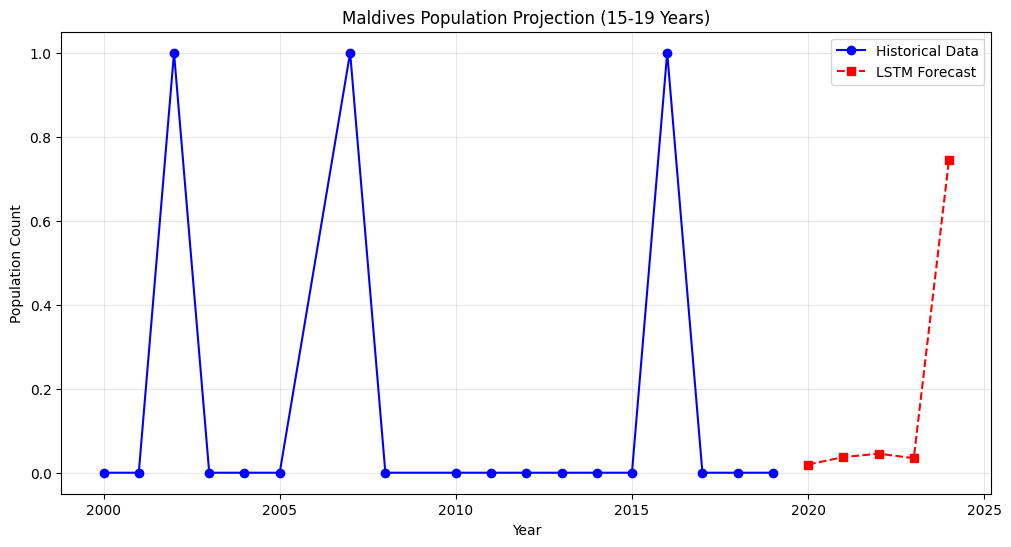

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Input

# 1. Load and Clean Data
# Strip spaces from column names to prevent KeyError: 'Year'
df.columns = df.columns.str.strip()
# Sort by Year to ensure the sequence is chronological
df = df.sort_values('Year')

target_col = '15-19 Years'
year_col = 'Year'

# 2. Scale the Target Data
data = df[target_col].values.reshape(-1, 1)
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data)

# 3. Create Training Sequences
lookback = 10

def create_sequences(data, lb):
    X, y = [], []
    for i in range(len(data) - lb):
        X.append(data[i : i + lb, 0])
        y.append(data[i + lb, 0])
    return np.array(X), np.array(y)

X_train, y_train = create_sequences(scaled_data, lookback)
# Reshape to [samples, time steps, features]
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))

# 4. Build the LSTM Model (Keras 3 Compliant)
model = Sequential([
    Input(shape=(lookback, 1)),
    LSTM(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(1)
])
model.compile(optimizer='adam', loss='mse')

# 5. Train the Model
print("Training model... please wait.")
model.fit(X_train, y_train, epochs=200, batch_size=2, verbose=0)

# 6. Future Prediction (Recursive Loop)
future_steps = 5
# Start with the last known window of data
current_window = scaled_data[-lookback:].reshape((1, lookback, 1))
future_forecast_scaled = []

for i in range(future_steps):
    # Predict the next step
    pred = model.predict(current_window, verbose=0)
    future_forecast_scaled.append(pred[0])

    # Slide the window: Drop oldest, add the prediction as the newest input
    new_input = pred.reshape(1, 1, 1)
    current_window = np.append(current_window[:, 1:, :], new_input, axis=1)

# 7. Inverse Scaling and Year Generation
future_forecast = scaler.inverse_transform(future_forecast_scaled)
last_year = int(df[year_col].iloc[-1])
future_years = np.arange(last_year + 1, last_year + 1 + future_steps)

# 8. Display and Plot
print("\n--- Next 5 Years Forecast ---")
for year, val in zip(future_years, future_forecast):
    print(f"Year {year}: {val[0]:.2f}")

plt.figure(figsize=(12, 6))
plt.plot(df[year_col], df[target_col], label='Historical Data', marker='o', color='blue')
plt.plot(future_years, future_forecast, label='LSTM Forecast', linestyle='--', marker='s', color='red')
plt.title(f"Maldives Population Projection ({target_col})")
plt.xlabel("Year")
plt.ylabel("Population Count")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [8]:
#Read the file and show all the rows

from google.colab import files
uploaded = files.upload()
import pandas as pd
df = pd.read_csv('data_Male.csv')
print(df)

Saving data_Male.csv to data_Male (1).csv
      Unnamed: 0 Region Name Country Name  Year   Sex  0 Year  1-4 Years  \
0              1      Africa   Cabo Verde  1980  Male     0.0        0.0   
1              3      Africa   Cabo Verde  2011  Male     0.0        0.0   
2              5      Africa        Egypt  1965  Male     0.0        0.0   
3              7      Africa        Egypt  1973  Male     0.0        0.0   
4              9      Africa        Egypt  1974  Male     0.0        0.0   
...          ...         ...          ...   ...   ...     ...        ...   
4716        9529     Oceania  New Zealand  2012  Male     0.0        0.0   
4717        9531     Oceania  New Zealand  2013  Male     0.0        0.0   
4718        9533     Oceania  New Zealand  2014  Male     0.0        0.0   
4719        9535     Oceania  New Zealand  2015  Male     0.0        0.0   
4720        9537     Oceania  New Zealand  2016  Male     0.0        0.0   

      5-9 Years  10-14 Years  15-19 Years  ..

In [9]:
#Feature Engineering - Country-wise datafile creation
for country, group in df.groupby('Country Name'):
    group.to_csv(f'data_{country}.csv')
    print(f"Created: data_{country}.csv")

Created: data_Albania.csv
Created: data_Antigua and Barbuda.csv
Created: data_Argentina.csv
Created: data_Armenia.csv
Created: data_Australia.csv
Created: data_Austria.csv
Created: data_Azerbaijan.csv
Created: data_Bahamas.csv
Created: data_Bahrain.csv
Created: data_Barbados.csv
Created: data_Belarus.csv
Created: data_Belgium.csv
Created: data_Belize.csv
Created: data_Bosnia and Herzegovina.csv
Created: data_Brazil.csv
Created: data_Brunei Darussalam.csv
Created: data_Bulgaria.csv
Created: data_Cabo Verde.csv
Created: data_Canada.csv
Created: data_Chile.csv
Created: data_China, Hong Kong SAR.csv
Created: data_Colombia.csv
Created: data_Costa Rica.csv
Created: data_Croatia.csv
Created: data_Cuba.csv
Created: data_Cyprus.csv
Created: data_Czechia.csv
Created: data_Denmark.csv
Created: data_Dominica.csv
Created: data_Dominican Republic.csv
Created: data_Ecuador.csv
Created: data_Egypt.csv
Created: data_El Salvador.csv
Created: data_Estonia.csv
Created: data_Fiji.csv
Created: data_Finland.

In [13]:
!pip install streamlit


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 64.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 81.8 MB/s eta 0:00:00


In [22]:
!pip install -q streamlit
!npm install -g localtunnel

⠙⠹⠸⠼⠴⠦⠧
changed 22 packages in 935ms
⠧
⠧3 packages are looking for funding
⠧  run `npm fund` for details
⠧

In [37]:
!npx localtunnel --port 8501 --host http://loca.lt

⠙⠹⠸⠼⠴⠦your url is: https://cold-taxes-sit.loca.lt


^C


In [26]:
!curl ipv4.icanhazip.com

34.59.47.160


In [30]:
%%writefile app.py
import streamlit as st
import pandas as pd

st.title("Grenada Data Explorer")

# Replaces google.colab files.upload()
uploaded_file = st.file_uploader("Upload your 'data_Grenada_m.csv' file", type=['csv'])

if uploaded_file is not None:
    # Read the uploaded CSV directly into a DataFrame
    df = pd.read_csv(uploaded_file)

    # Display the DataFrame interactively
    st.subheader("Raw Data Preview")
    st.dataframe(df)

    # Optional: Display some quick stats
    st.subheader("Data Summary")
    st.write(df.describe())
else:
    st.info("Please upload a CSV file to begin.")

Overwriting app.py


In [32]:
!streamlit run app.py --server.port 8501 &>/content/logs.txt &

In [33]:
!pip install pyngrok -q
from pyngrok import ngrok

# Authenticate (Only need to do this once)
ngrok.set_auth_token("3DQd2YIuMA0Aoo2tNeGB5SoUmG8_3eYowwLbHJzABmiMgz7j")

# Connect the tunnel to the Streamlit port
public_url = ngrok.connect(8501)
print(f"Click here to open your app: {public_url}")

Click here to open your app: NgrokTunnel: "https://foothill-wager-hangover.ngrok-free.dev" -> "http://localhost:8501"
